# Chunking and Embedding Data

Large Language Models are powerful, but they suffer from **hallucinations** - generating fluent text that is factually wrong. They also cannot access private data or information that arrived after their training cutoff. **Retrieval-Augmented Generation (RAG)** solves this by fetching relevant documents at query time and feeding them to the LLM as grounding context.


At the heart of every RAG system are **embeddings** (dense vectors that capture meaning) and **vector stores** (databases optimised for fast similarity search over those vectors). 

We will walk through the embedding pipeline here:
- **Chunking**: splitting documents into retrieval-friendly pieces
- **Embeddings**: generating semantic embedding vectors
- **Vector DBs and CRUD Operations**: storing embeddings into vector databases and performing CRUD operations
- **Semantic Search**: side-by-side comparison of retrieval across all three stores

#### Setup

In [1]:
# %pip install -q langchain langchain-text-splitters sentence-transformers 

In [2]:
import numpy as np, pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Chunking Strategies

Real-world documents, like articles, manuals, codebases, are far too long to embed as a single vector. Embedding models have a limited context window, and even when they accept longer inputs, the resulting vector becomes a diluted average of too many ideas, hurting retrieval precision.

**Chunking** is the process of splitting documents into smaller, semantically focused pieces before embedding. It is one of the most impactful design decisions in a RAG pipeline. Key trade-offs include:
- **Chunk size**: Smaller chunks (100-200 tokens) give precise retrieval but may lack context. Larger chunks (500-1000 tokens) preserve context but dilute the embedding signal.
- **Overlap**: Adjacent chunks should share some tokens (typically 10-20%) so that information at chunk boundaries is not lost
- **Splitting strategy**: Naive character-count splits can cut sentences in half. Smarter strategies split on paragraph breaks, sentence boundaries, or even semantic topic shifts.

#### Loading Documents

We have some example PDF files of a few policy documents. Let's try loading these and understanding the different chunking techniques.

To load a PDF, we can use the open-source library `pypdf`. It offers several other PDF-related operations as well (visit the official documentation to know more). Install it using `pip install pypdf`.

In [3]:
from pypdf import PdfReader

def load_pdf(path):
    # create a pdf reader object
    reader = PdfReader(path)
    text = ""
    
    # iterating over the list of page objects read from the document, to extract the text in each page
    for page in reader.pages:
        page_text = page.extract_text()
        if page_text:
            text += page_text + "\n"
    
    return text

In [4]:
text = load_pdf("data/Policy Documents/HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay.pdf")
print(text)

 
 
            Part A 
<<Date>> 
<<Policyholder’s Name>>  
<<Policyholder’s Address>> 
<<Policyholder’s Contact Number>> 
 
Dear <<Policyholder’s Name>>,  
 
Sub: Your Policy no. <<  >> 
We are glad to inform you that your proposal has been accepted and the HDFC Life Easy Health (“Policy”) 
being this document, has been issued. We have made every effort to design your Policy in a simple format. We 
have highlighted items of importance so that you may recognize them easily. 
 
Policy document: 
As an evidence of the insurance contract between HDFC Life Insurance Company Limited and you, the Policy 
is enclosed herewith. Please preserve this document safely and also inform your nominees about the same. A 
copy of your proposal form and other relevant documents submitted by you is also enclosed for your 
information and record.  
 
Cancellation in the Free-Look Period: 
 
<< In case you are not agreeable to any of the terms and conditions stated in the Policy, you have the option to 
ret

In [5]:
print(f"Document length: {len(text)} characters")

Document length: 83217 characters


### Fixed-Size Chunking

Split text by a constant character length

In [6]:
def fixed_length_chunk(text, chunk_size=500):
    chunks = []
    
    for i in range(0, len(text), chunk_size):
        chunks.append(text[i:i+chunk_size])
    
    return chunks


chunks = fixed_length_chunk(text, 500)

In [7]:
# see the first 5 chunks
chunks[:5]

[' \n \n            Part A \n<<Date>> \n<<Policyholder’s Name>>  \n<<Policyholder’s Address>> \n<<Policyholder’s Contact Number>> \n \nDear <<Policyholder’s Name>>,  \n \nSub: Your Policy no. <<  >> \nWe are glad to inform you that your proposal has been accepted and the HDFC Life Easy Health (“Policy”) \nbeing this document, has been issued. We have made every effort to design your Policy in a simple format. We \nhave highlighted items of importance so that you may recognize them easily. \n \nPolicy document: \n',
 'As an evidence of the insurance contract between HDFC Life Insurance Company Limited and you, the Policy \nis enclosed herewith. Please preserve this document safely and also inform your nominees about the same. A \ncopy of your proposal form and other relevant documents submitted by you is also enclosed for your \ninformation and record.  \n \nCancellation in the Free-Look Period: \n \n<< In case you are not agreeable to any of the terms and conditions stated in the Polic

This is the simplest chunking strategy. We can see the list of chunked contents.

However, many sentences are cut in between. We can also add overlaps to retain the context better.

#### Sliding-Window Chunking

In [8]:
def fixed_length_chunk_overlap(text, chunk_size=500, overlap=50):
    chunks = []
    
    step = chunk_size - overlap
    
    for i in range(0, len(text), step):
        chunk = text[i:i + chunk_size]
        chunks.append(chunk)
    
    return chunks


overlapped_chunks = fixed_length_chunk_overlap(text)

In [9]:
overlapped_chunks[:3]

[' \n \n            Part A \n<<Date>> \n<<Policyholder’s Name>>  \n<<Policyholder’s Address>> \n<<Policyholder’s Contact Number>> \n \nDear <<Policyholder’s Name>>,  \n \nSub: Your Policy no. <<  >> \nWe are glad to inform you that your proposal has been accepted and the HDFC Life Easy Health (“Policy”) \nbeing this document, has been issued. We have made every effort to design your Policy in a simple format. We \nhave highlighted items of importance so that you may recognize them easily. \n \nPolicy document: \n',
 'u may recognize them easily. \n \nPolicy document: \nAs an evidence of the insurance contract between HDFC Life Insurance Company Limited and you, the Policy \nis enclosed herewith. Please preserve this document safely and also inform your nominees about the same. A \ncopy of your proposal form and other relevant documents submitted by you is also enclosed for your \ninformation and record.  \n \nCancellation in the Free-Look Period: \n \n<< In case you are not agreeable t

Now you can see the chunks have text overlapping with the previous and next ones. We can also call it **sliding window** chunking.

### Natural Delimiter Based Chunking

Split using structural separators such as headings or blank lines.

In [10]:
def delimiter_chunk(text, delimiter="\n"):
    chunks = text.split(delimiter)
    
    return [c.strip() for c in chunks if c.strip()]


chunks = delimiter_chunk(text)

# Try with the following arguments
# delimiter = "\n#"
# delimiter = "\n\n"
# delimiter = "\n-"

In [11]:
chunks

['Part A',
 '<<Date>>',
 '<<Policyholder’s Name>>',
 '<<Policyholder’s Address>>',
 '<<Policyholder’s Contact Number>>',
 'Dear <<Policyholder’s Name>>,',
 'Sub: Your Policy no. <<  >>',
 'We are glad to inform you that your proposal has been accepted and the HDFC Life Easy Health (“Policy”)',
 'being this document, has been issued. We have made every effort to design your Policy in a simple format. We',
 'have highlighted items of importance so that you may recognize them easily.',
 'Policy document:',
 'As an evidence of the insurance contract between HDFC Life Insurance Company Limited and you, the Policy',
 'is enclosed herewith. Please preserve this document safely and also inform your nominees about the same. A',
 'copy of your proposal form and other relevant documents submitted by you is also enclosed for your',
 'information and record.',
 'Cancellation in the Free-Look Period:',
 '<< In case you are not agreeable to any of the terms and conditions stated in the Policy, you ha

Most PDFs convert paragraphs into blocks separated by blank lines. If you use the delimiter `\n\n`, it would be **paragraph-based chunking**.

### Sentence-Based Chunking

We will use sentence tokenisation here. This is offered by the `nltk` (natural language toolkit) library. The NLTK Punkt models (`punkt_tab`) are primarily used for sentence tokenisation.

In [12]:
# %pip install nltk

In [13]:
import nltk
nltk.download('punkt_tab')

from nltk.tokenize import sent_tokenize

def sentence_chunk(text):
    return sent_tokenize(text)


sentence_chunks = sentence_chunk(text)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/navneet/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [14]:
sentence_chunks

[' \n \n            Part A \n<<Date>> \n<<Policyholder’s Name>>  \n<<Policyholder’s Address>> \n<<Policyholder’s Contact Number>> \n \nDear <<Policyholder’s Name>>,  \n \nSub: Your Policy no.',
 '<<  >> \nWe are glad to inform you that your proposal has been accepted and the HDFC Life Easy Health (“Policy”) \nbeing this document, has been issued.',
 'We have made every effort to design your Policy in a simple format.',
 'We \nhave highlighted items of importance so that you may recognize them easily.',
 'Policy document: \nAs an evidence of the insurance contract between HDFC Life Insurance Company Limited and you, the Policy \nis enclosed herewith.',
 'Please preserve this document safely and also inform your nominees about the same.',
 'A \ncopy of your proposal form and other relevant documents submitted by you is also enclosed for your \ninformation and record.',
 'Cancellation in the Free-Look Period: \n \n<< In case you are not agreeable to any of the terms and conditions stated 

The chunks are now more aligned with sentence-boundaries. However, still the splits may not align semantically. Let's try semantic chunking.

### Semantic Chunking

We will calculate semantic similarity between sentences and keep grouping them until the new sentences fall below a similarity threshold for a sentence group.

In [15]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

def semantic_chunk(text, threshold=0.75, sentences=sentence_chunks):
    
    embeddings = model.encode(sentences)
    
    chunks = []
    current_chunk = [sentences[0]]
    
    for i in range(1, len(sentences)):
        
        # dot product between the vector embeddings
        sim = np.dot(embeddings[i-1], embeddings[i]) / (
            np.linalg.norm(embeddings[i-1]) * np.linalg.norm(embeddings[i])
        )
        
        # when similarity drops below threshold, break the chunks
        if sim < threshold:
            chunks.append(" ".join(current_chunk))
            current_chunk = []
        
        current_chunk.append(sentences[i])
    
    if current_chunk:
        chunks.append(" ".join(current_chunk))
    
    return chunks


chunks = semantic_chunk(text)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [16]:
chunks

[' \n \n            Part A \n<<Date>> \n<<Policyholder’s Name>>  \n<<Policyholder’s Address>> \n<<Policyholder’s Contact Number>> \n \nDear <<Policyholder’s Name>>,  \n \nSub: Your Policy no.',
 '<<  >> \nWe are glad to inform you that your proposal has been accepted and the HDFC Life Easy Health (“Policy”) \nbeing this document, has been issued.',
 'We have made every effort to design your Policy in a simple format.',
 'We \nhave highlighted items of importance so that you may recognize them easily.',
 'Policy document: \nAs an evidence of the insurance contract between HDFC Life Insurance Company Limited and you, the Policy \nis enclosed herewith.',
 'Please preserve this document safely and also inform your nominees about the same.',
 'A \ncopy of your proposal form and other relevant documents submitted by you is also enclosed for your \ninformation and record.',
 'Cancellation in the Free-Look Period: \n \n<< In case you are not agreeable to any of the terms and conditions stated 

In [17]:
len(sentence_chunks), len(chunks)

(439, 429)

We can see that some of the sentences have been grouped based on similarity

## Using LangChain Splitters

### LangChain Document Loaders

In [18]:
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader

You already know how to use LangChain document loaders. Let's load the PDFs for chunking.

We will use the `PyPDFLoader` for reading the PDFs, and the `DirectoryLoader`, which helps to load the files inside a directory.

##### Chunking for multiple documents

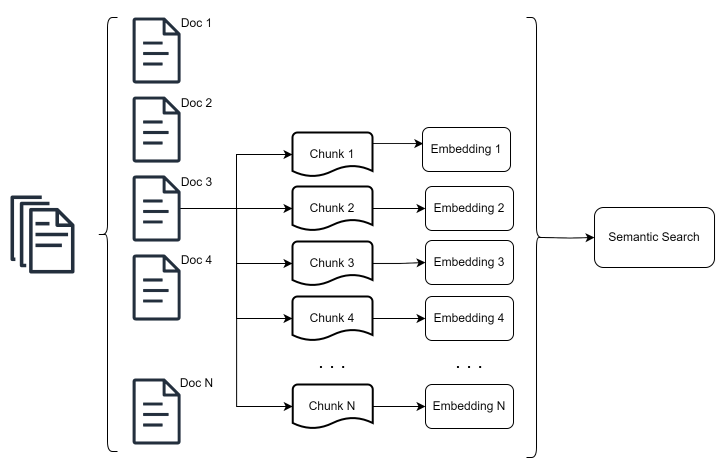

In [19]:
dir_path = "data/Policy Documents"

loader = DirectoryLoader(
    dir_path,
    glob="*.pdf",   # We use only files ending in .pdf
    loader_cls=PyPDFLoader
)

In [20]:
documents = loader.load()

print(f"Total documents loaded: {len(documents)}")

# 
print("\nFirst document preview:")
print(documents[0].page_content[:500])

Total documents loaded: 217

First document preview:
F&U dated 15th October 2022                  UIN-101N169V02  P a g e  | 0                        
 
 
 
 
 
   HDFC Life Group Term Life 
 
OF 
 
 
«OWNERNAME» 
 
 
 
 
 
  
Based on the Proposal and the declarations and 
any 
statement made or referred to therein, 
We will pay the Benefits mentioned in this Policy 
subject to the terms and conditions contained 
herein 
 
 
 
 
 
 
<< Designation of the Authorised Signatory >>


The loader itself splits the files into multiple documents, based on structure.

However, this is not enough for chunking. In case of very small documents or if the loader produces semantic sections, we may not need chunking. But for these PDFs, we will need it. Let's now learn about LangChain's data and retrieval related tools. The first one is text splitter.

### LangChain Text Splitters

In [21]:
from langchain_text_splitters import (
    CharacterTextSplitter,
    RecursiveCharacterTextSplitter,
    TokenTextSplitter,
)

In [22]:
def show_chunks(splitter_name, chunks):
    print(f" {splitter_name} — {len(chunks)} chunks \n\n")
    
    for i, chunk in enumerate(chunks):
        text = chunk.page_content
        
        print(f"\nChunk {i+1} ({len(text)} chars)")
        print(text[:200] + ("..." if len(text) > 200 else ""))

#### Fixed-Size Character Splitting

In [23]:
# Fixed-size character splitting using CharacterTextSplitter()
char_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=300,
    chunk_overlap=50,
)

In [24]:
# To split a list of document objects
char_chunks = char_splitter.split_documents(documents)
show_chunks("CharacterTextSplitter (size=300, overlap=50)", char_chunks)

 CharacterTextSplitter (size=300, overlap=50) — 2368 chunks 



Chunk 1 (265 chars)
F&U dated 15th October 2022                  UIN-101N169V02  P a g e  | 0                        
 
 
 
 
 
   HDFC Life Group Term Life 
 
OF 
 
 
«OWNERNAME» 
 
 
 
 
 
  
Based on the Proposal and ...

Chunk 2 (208 chars)
any 
statement made or referred to therein, 
We will pay the Benefits mentioned in this Policy 
subject to the terms and conditions contained 
herein 
 
 
 
 
 
 
<< Designation of the Authorised Sign...

Chunk 3 (146 chars)
F&U dated 15th October 2022                  UIN-101N169V02  P a g e  | 1                        
 
 
PART A: Covering Letter with Policy Schedule

Chunk 4 (282 chars)
PART A: Covering Letter with Policy Schedule 
                                                                                                                                                <dd-mm-yyy...

Chunk 5 (267 chars)
__________________ 
__________________ 
__________________ 
 
 
Your HDFC

In [25]:
type(char_chunks)

list

This is a list of document objects. Each chunk still keeps metadata.

We can use the following chunk attributes for specifics:
```Python
print(char_chunks[0].page_content)
print(char_chunks[0].metadata)
```

In [26]:
# we can also split a single document using split_text()
doc = documents[0]
char_chunks = char_splitter.split_text(doc.page_content)
char_chunks

['F&U dated 15th October 2022                  UIN-101N169V02  P a g e  | 0                        \n \n \n \n \n \n   HDFC Life Group Term Life \n \nOF \n \n \n«OWNERNAME» \n \n \n \n \n \n  \nBased on the Proposal and the declarations and \nany \nstatement made or referred to therein,',
 'any \nstatement made or referred to therein, \nWe will pay the Benefits mentioned in this Policy \nsubject to the terms and conditions contained \nherein \n \n \n \n \n \n \n<< Designation of the Authorised Signatory >>']

| Method              | Input          | Output         |
| ------------------- | -------------- | -------------- |
| `split_text()`      | `string`         | `list[str]`      |
| `split_documents()` | `list[Document`] | `list[Document]` |


#### Token-Based Splitting

In [27]:
# Token-based splitting using TokenTextSplitter()
token_splitter = TokenTextSplitter(
    chunk_size=60,
    chunk_overlap=10
)
token_chunks = token_splitter.split_documents(documents)
show_chunks("TokenTextSplitter (size=60 tokens, overlap=10)", token_chunks)

 TokenTextSplitter (size=60 tokens, overlap=10) — 3085 chunks 



Chunk 1 (92 chars)
F&U dated 15th October 2022                  UIN-101N169V02  P a g e  | 0                   

Chunk 2 (87 chars)
               
 
 
 
 
 
   HDFC Life Group Term Life 
 
OF 
 
 
«OWNERNAME» 
 
 
 
 


Chunk 3 (212 chars)
 
 
 
 
 
 
  
Based on the Proposal and the declarations and 
any 
statement made or referred to therein, 
We will pay the Benefits mentioned in this Policy 
subject to the terms and conditions conta...

Chunk 4 (105 chars)
 to the terms and conditions contained 
herein 
 
 
 
 
 
 
<< Designation of the Authorised Signatory >>

Chunk 5 (92 chars)
F&U dated 15th October 2022                  UIN-101N169V02  P a g e  | 1                   

Chunk 6 (95 chars)
               
 
 
PART A: Covering Letter with Policy Schedule 
                             

Chunk 7 (60 chars)
                                                            

Chunk 8 (60 chars)
                                

#### Recursive Character Splitting

This is the LangChain's default structure-aware chunking technique

In [28]:
# Recursive character splitting
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""]
)
recursive_chunks = recursive_splitter.split_documents(documents)
show_chunks("RecursiveCharacterTextSplitter (size=300, overlap=50)", recursive_chunks)

 RecursiveCharacterTextSplitter (size=300, overlap=50) — 2373 chunks 



Chunk 1 (265 chars)
F&U dated 15th October 2022                  UIN-101N169V02  P a g e  | 0                        
 
 
 
 
 
   HDFC Life Group Term Life 
 
OF 
 
 
«OWNERNAME» 
 
 
 
 
 
  
Based on the Proposal and ...

Chunk 2 (208 chars)
any 
statement made or referred to therein, 
We will pay the Benefits mentioned in this Policy 
subject to the terms and conditions contained 
herein 
 
 
 
 
 
 
<< Designation of the Authorised Sign...

Chunk 3 (146 chars)
F&U dated 15th October 2022                  UIN-101N169V02  P a g e  | 1                        
 
 
PART A: Covering Letter with Policy Schedule

Chunk 4 (282 chars)
PART A: Covering Letter with Policy Schedule 
                                                                                                                                                <dd-mm-yyy...

Chunk 5 (267 chars)
__________________ 
__________________ 
__________________ 
 
 


---
## Generating Embeddings

An **embedding** is a fixed-length dense vector (e.g., 384 or 768 floats) that represents a piece of text in a continuous vector space. The key property is that semantically similar texts land close together in this space, even when they share no words. This is what makes vector-based retrieval possible, we convert both documents and queries into embeddings and then find the nearest neighbours.

Embedding models are typically transformer-based encoders trained with contrastive objectives: they learn to pull related pairs closer and push unrelated pairs apart. The `all-MiniLM-L6-v2` model is a popular open-source choice. It produces 384-dimensional vectors, runs fast on CPU, and requires no API key.

In [31]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [32]:
texts = [doc.page_content for doc in recursive_chunks]

embeddings = embedding_model.encode(texts)

This creates a numpy array like object with the shape `(num_chunks, embedding_dimension)`.

In [30]:
print(f"Number of documents : {len(recursive_chunks)}")
print(f"Embedding dimension : {embeddings.shape[1]}")
print(f"Embedding dtype     : {embeddings.dtype}")
print(f"\nFirst embedding (truncated): {embeddings[0][:10]}...")

Number of documents : 2373


NameError: name 'embeddings' is not defined

### Saving Embeddings to File

The data structure after embedding is essentially `List[List[float]]`. Each vector corresponds to one chunk. We can save these embeddings to a CSV.

In [ ]:
embeddings

array([[-1.9127546e-02,  4.5740478e-02,  4.0459327e-02, ...,
         8.4379157e-03,  8.8717146e-03,  3.7174132e-02],
       [-5.3117909e-02,  1.3370451e-01,  1.6761748e-02, ...,
         7.9868801e-02, -1.5701298e-02,  1.9088030e-02],
       [-2.8918492e-02,  9.5611736e-02, -3.3749919e-05, ...,
         1.2133545e-02,  3.8063344e-02,  9.1518238e-02],
       ...,
       [-3.4620963e-02,  1.4479357e-01,  4.3786503e-03, ...,
        -1.9051487e-02,  4.4806447e-02,  3.0560745e-03],
       [ 2.8126440e-03,  8.1835456e-02,  2.3962267e-02, ...,
         2.6427519e-02,  7.5052730e-03, -3.2737926e-02],
       [ 1.3828637e-02,  1.0675493e-03, -1.3882182e-02, ...,
         2.9347096e-02,  1.6194543e-01,  4.5116525e-03]],
      shape=(2373, 384), dtype=float32)

In [ ]:
# We can add the chunk text, metadata and source details to the embeddings before storing it as a CSV

data = []

for doc, emb in zip(recursive_chunks, embeddings):
    data.append({
        "text": doc.page_content,
        "source": doc.metadata.get("source"),
        "page": doc.metadata.get("page"),
        "embedding": emb.tolist()
    })

In [ ]:
# For now, we only need the raw embeddings
data = []
for emb in embeddings:
    data.append(emb.tolist())

In [ ]:
df = pd.DataFrame(data)

df.to_csv("data/embeddings/rag_embeddings.csv", index=False)

NameError: name 'data' is not defined